In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from scipy.stats import percentileofscore
import scipy

import cartopy.crs as ccrs
import os

In [6]:
'''
d4PDF land-sea mask
'''
example = xr.open_dataset('/nesi/project/niwa02986/deansm/data/d4pdf/NZ/HPB/mon/TA/TA_Aday_d4PDF_HPB_m001_1951-2011.nc')
# d4PDF land-sea mask
lsm = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/sftlf_fx_d4PDF_HPB_m000_000000-000000.nc')
lsm = lsm.isel(time=0).drop('time')
lsm = lsm.sel(lon = slice(165,180),lat=slice(-48,-33))
lsm = lsm.interp(lat=example.lat,lon=example.lon)

seasons_a = ['autumn','winter','spring','summer']
lower_var = {'TA':'ta','PRECIPI':'precipi','ROF':'rof'}


/nesi/project/niwa00015/queenle/seaborn_env/lib/python3.8/site-packages/xarray/coding/times.py:152: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


In [48]:
'''
rewrite file names
'''
import re

ensemble = ['m001', 'm002', 'm003', 'm004', 'm005', 'm006', 'm007', 'm008', 'm009', 'm010', 'm011', 'm012', 'm013', 'm014', 'm015', 'm016', 'm017', 'm018', 'm019', 'm020', 'm021', 'm022', 'm023', 'm024', 'm025', \
            'm026', 'm027', 'm028', 'm029', 'm030', 'm031', 'm032', 'm033', 'm034', 'm035', 'm036', 'm037', 'm038', 'm039', 'm040', 'm041', 'm042', 'm043', 'm044', 'm045', 'm046', 'm047', 'm048', 'm049', 'm050', \
            'm051', 'm052', 'm053', 'm054', 'm055', 'm056', 'm057', 'm058', 'm059', 'm060', 'm061', 'm062', 'm063', 'm064', 'm065', 'm066', 'm067', 'm068', 'm069', 'm070', 'm071', 'm072', 'm073', 'm074', 'm075', \
            'm076', 'm077', 'm078', 'm079', 'm080', 'm081', 'm082', 'm083', 'm084', 'm085', 'm086', 'm087', 'm088', 'm089', 'm090', 'm091', 'm092', 'm093', 'm094', 'm095', 'm096', 'm097', 'm098', 'm099', 'm100']

input_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'

for var in ['ROF','TA','PRECIPI']:
    
    directory = input_dir+var+'/seasonal/means/'
    
    for scen in ['all','nat']:
        
        for mem in ensemble:
            
            for season in ['winter','spring','summer','autumn']:

                old_file_name = directory+'d4PDF_'+scen+'_'+season+'_'+var+'_gaussian_mean_sub_'+re.findall(r'\d+', mem)[0]+'_.nc'
                new_file_name = directory+'d4PDF_'+scen+'_'+season+'_'+var+'_gaussian_mean_sub_'+mem+'_.nc'

                try:
                    os.system('mv '+old_file_name+' '+new_file_name)
                except:
                    continue
                    

In [18]:
'''
Create ensemble means based on gaussian ensemble members for annual, seasonal pr
'''

input_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'

for var in ['ROF','TA','PRECIPI']:
    
    directory = input_dir+var+'/seasonal/'
    
    for scen in ['all','nat']:

        file_name = ["d4PDF_"+scen+"_","_"+var+"_gaussian_",".nc"]

        for s in ['winter','spring','summer','autumn']:

            da_list = []
            member_list = []
            for ens_mem in ensemble:
                member_list.append(ens_mem)

                file_path = directory + file_name[0]+s+file_name[1]+ens_mem+file_name[2]
                ens_mem_season = xr.open_dataarray(file_path)

                da_list.append(ens_mem_season)

            ens_ds = xr.concat(da_list,dim='member')
            ens_ds['member']=member_list

            # full ensemble mean
            ens_ds.mean('member').to_netcdf(directory+'means/'+file_name[0]+s+file_name[1]+"ensMean"+file_name[2])

            # means without members
            for mem in member_list:
                ens_ds.where(ens_ds.member != mem).mean('member').to_netcdf(directory+'means/'+file_name[0]+s+file_name[1]+"mean_sub_"+mem+'_'+file_name[2])
    

In [26]:
def q_map_to_gaussian(da, dist):
    
    # create container for corrected values
    gaussian = []
    
    for lat in da.lat:
        for lon in da.lon:

            ts = da.sel(lat=lat,lon=lon).values.flatten()
            epsilon = 1e-6  # or smaller, depending on your data's precision
            ts = ts + epsilon * np.random.randn(*ts.shape)

            full_dist = dist.sel(lat=lat,lon=lon).values.flatten()
            full_dist = full_dist + epsilon * np.random.randn(*full_dist.shape)
            
            if np.isnan(np.sum(ts)):
                corrected_ts = [np.nan for i in range(len(ts))]

            else:
                corrected_ts = []
                for val in ts:

                    # find percentile of value within the distribution of observations
                    percentile = percentileofscore(full_dist, val, kind= 'mean')
                                        
                    #if percentile == 100 or percentile == 0:
                    #    print('issue')

                    # replace with corresponding percentile value in norm distribution
                    corrected_ts.append(scipy.stats.norm.ppf(percentile/100, loc=0, scale=1))

            gaussian.append(corrected_ts)

    gaussian = np.array(gaussian).reshape((len(da.lat),len(da.lon),len(da.time)))
    
    gaussian_da = xr.DataArray(data = gaussian,
                               dims = ('lat', 'lon','time'),
                               coords = {'lat':da.lat.values,
                                         'lon':da.lon.values,
                                         'time':da.time.values
                                        }
                               )
    return(gaussian_da)


In [23]:
da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/ROF/seasonal/perturbed/d4PDF_all_autumn_ROF_gaussian_m001.nc')

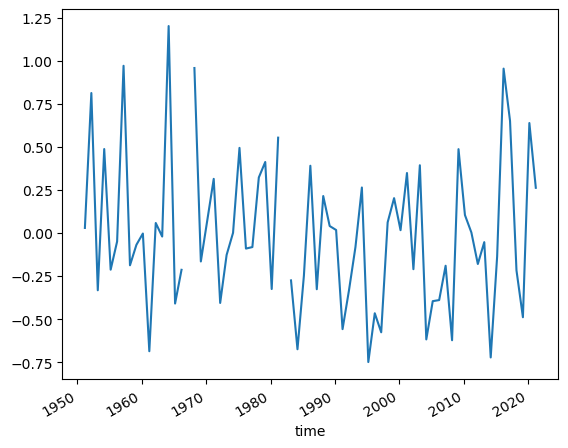

In [25]:
da.mean(['lat','lon']).plot()

In [29]:
'''
Quantile mapping to normal distribution
'''

for var in ['ROF']:#,'TA','PRECIPI']:
    print(var)
    for scen in ['all']:#,'nat']:
        print(scen)
        
        if scen == 'all':
            path = '/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB/'+var+'/'
            file_name_setup = [var+'_Amon_d4PDF_HPB_m','_1951-2021.nc']

        if scen == 'nat':
            path = '/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB_NAT/'+var+'/'
            file_name_setup = [var+'_Amon_d4PDF_HPB_NAT_m','_1951-2021.nc']

        for ens_mem in range(3,101):

            print(ens_mem)

            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
                
            file_path = path + file_name_setup[0]+number+file_name_setup[1]
            ens_mem = xr.open_dataset(file_path)

            ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-48,-33))
            ens_mem = ens_mem[lower_var[var]].where(lsm.sftlf > 0)

            ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()

            for i,s in enumerate([3,6,9,12]):

                full_seasonal_dist = xr.open_dataset("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/full_dists/"+var+"/" + var + "_"+scen+"_" + seasons_a[i] + "_full_distribution.nc")
                full_seasonal_dist = full_seasonal_dist[lower_var[var]]
                #print(full_seasonal_dist)
                
                ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

                ens_mem_season_gaussian = q_map_to_gaussian(ens_mem_season,full_seasonal_dist)
                ens_mem_season_gaussian.to_netcdf(f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/{var}/seasonal/perturbed/d4PDF_{scen}_{seasons_a[i]}_{var}_gaussian_m{number}.nc')
                
                #ens_mem_season.to_netcdf("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/"+var+"/full/" + file_name_setup[0] + number + "_raw_" +seasons_a[i] + file_name_setup[1])

                

ROF
all
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [ ]:
d4PDF_scen_seasongoeshere_ROF_gaussian

In [18]:
'''
Creating dataarrays of FULL distributions for ALL and NAT scenarios (concatenate all ensemble members over time)
'''


for var in ['ROF']:#,'TA','PRECIPI']:#,'ROFS']:
    print(var)
    
    for scen in ['all','nat']:
        
        if scen == 'all':
            print('all')
            path = '/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB/'+var+'/'
            file_name_setup = [var+'_Amon_d4PDF_HPB_m','_1951-2021.nc']

        if scen == 'nat':
            print('nat')
            path = '/nesi/project/niwa02986/queenle/data/d4pdf/NZ/HPB_NAT/'+var+'/'
            file_name_setup = [var+'_Amon_d4PDF_HPB_NAT_m','_1951-2021.nc']

        seasonal_das = {3:[],6:[],9:[],12:[]}
        for ens_mem in range(1,101):
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

            file_path = path + file_name_setup[0]+number+file_name_setup[1]
            ens_mem = xr.open_dataset(file_path)

            ens_mem = ens_mem.sel(lon = slice(165,180),lat=slice(-48,-33))
            ens_mem = ens_mem[lower_var[var]].where(lsm.sftlf > 0)

            ens_mem_seasonal = ens_mem.resample(time='QS-DEC').mean()

            for s in [3,6,9,12]:
                ens_mem_season = ens_mem_seasonal.sel(time=ens_mem_seasonal.time.dt.month.isin([s]))

                seasonal_das[s].append(ens_mem_season)

        for i,s in enumerate([3,6,9,12]):
            season_full_dist = xr.concat(seasonal_das[s],dim="time")
            season_full_dist.to_netcdf("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/full_dists/"+var+"/" + var + "_" + scen + "_" + seasons_a[i] + "_full_distribution.nc")



ROF
all
3
6
9
12
nat
3
6
9
12
TA
all
3
6
9
12
nat
3
6
9
12
PRECIPI
all
3
6
9
12
nat
3
6
9
12


In [6]:
'''
Create full ensemble means for raw data
'''

for var in ['TA','PRECIPI','ROF']:
    print(var)
    for scen in ['all','nat']:

        print(scen)
        
        if scen == 'all':
            file_name_setup = [var+'_Amon_d4PDF_HPB_m','_1951-2021.nc']
        if scen == 'nat':
            file_name_setup = [var+'_Amon_d4PDF_HPB_NAT_m','_1951-2021.nc']
        
        for i,s in enumerate([3,6,9,12]):
            print(s)

            da_list = []
            for ens_mem in range(1,101):
                if ens_mem == 100:
                    number = '100'
                else:
                    number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
                    
                ens_mem_season = xr.open_dataarray("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/"+var+"/full/" + file_name_setup[0] + number + "_raw_" + seasons_a[i] + file_name_setup[1])

                da_list.append(ens_mem_season)

            season_ens_mean = sum(da_list)/len(da_list)
            season_ens_mean.to_netcdf('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/'+var+'/full/means/' + file_name_setup[0][:-1] + 'FullEnsMean' + "_raw_" + seasons_a[i] + file_name_setup[1])

                

TA
all
3
6
9
12
nat
3
6
9
12
PRECIPI
all
3
6
9
12
nat
3
6
9
12
ROF
all
3
6
9
12
nat
3
6
9
12


In [4]:
seasons_a = ['autumn','winter','spring','summer']
lower_var = {'TA':'ta','PRECIPI':'precipi','ROF':'rof'}